
# Milestone 1 - Análisis Exploratorio de Datos (EDA)

## Proyecto: Infracciones de tránsito por tipo y zona

En este notebook se presenta la limpieza de datos, el análisis exploratorio univariado y bivariado, y una interpretación de los hallazgos principales del dataset de infracciones de tránsito.



## 1. Importación de librerías y carga del dataset

En esta sección se importan las librerías necesarias para el análisis y se carga el archivo fuente en formato Excel.


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuración visual
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# configuración de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ruta del dataset
ruta_archivo = os.path.join("data", "infracciones_de_transito_por_tipo_y_zona.xlsx")

# cargar dataset
df = pd.read_excel(ruta_archivo)

# mostrar primeras filas
df.head()


,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción
0,'99999999000006122775,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,C15,377456,TR TOLUVIEJO SINCELEJO - KM 15+300
1,'99999999000006122726,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,D01,754912,TR TOLUVIEJO SINCELEJO - KM 15+300
2,'99999999000006122776,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,D01,1207860,TR TOLUVIEJO SINCELEJO - KM 15+300
3,'99999999000006122782,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,C24,603930,TR TOLUVIEJO SINCELEJO - KM 15+300
4,'99999999000006124383,2025-01-01,Sampues - Dptal Sucre,Cédula,87*****,ARIEL CAYETANO,D13,1207860,VI SANONOFRECRUZDELVISO - KM 21+300


## 2. Exploración inicial del dataset

In [7]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
df.info()


Dimensiones del dataset: (33475, 9)

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 33475 entries, 0 to 33474
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Nro Comparendo           33475 non-null  str           
 1   Fecha Comparendo         33475 non-null  datetime64[us]
 2   Secretaría               33475 non-null  str           
 3   Tipo Documento           33475 non-null  str           
 4   Cédula Infractor         33475 non-null  str           
 5   Nombre                   33475 non-null  str           
 6   Infracciones Comparendo  33475 non-null  str           
 7   Valor                    33475 non-null  int64         
 8   Dirección Infracción     33475 non-null  str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 2.3 MB


In [8]:

df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Nro Comparendo,33475,33473,'99999999000006234980,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha Comparendo,33475,NaN,NaN,NaN,2025-07-09 13:59:18.488424,2025-01-01 00:00:00,2025-05-15 00:00:00,2025-07-11 00:00:00,2025-09-10 00:00:00,2025-11-12 00:00:00,NaN
Secretaría,33475,1,Sampues - Dptal Sucre,33475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipo Documento,33475,8,Cédula,29949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cédula Infractor,33475,4125,925*****,617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre,33475,7783,JOSE,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Infracciones Comparendo,33475,38,C29,9569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Valor,"33,475.00",NaN,NaN,NaN,"748,615.41",0.00,"603,930.00","603,930.00","1,207,860.00","28,988,640.00","335,079.27"
Dirección Infracción,33475,1555,MORROA-SINCELEJO RUTA 2515 PR 4+530,9745,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### Interpretación inicial

Se observa un dataset con variables mixtas: fechas, variables categóricas y una variable numérica principal (`Valor`). Esta exploración inicial permite validar la estructura general antes de comenzar la limpieza.


## 3. Limpieza y preparación de datos

In [9]:
# Copia de trabajo
_df_original = df.copy()

# Verificación de nulos
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)

# Verificación de duplicados
print("\nRegistros duplicados:", df.duplicated().sum())


Valores nulos por columna:
Nro Comparendo             0
Fecha Comparendo           0
Secretaría                 0
Tipo Documento             0
Cédula Infractor           0
Nombre                     0
Infracciones Comparendo    0
Valor                      0
Dirección Infracción       0
dtype: int64

Registros duplicados: 0


In [10]:

# Eliminación de duplicados si existen
df = df.drop_duplicates().copy()

# Conversión de fecha
df["Fecha Comparendo"] = pd.to_datetime(df["Fecha Comparendo"], errors="coerce")

# Creación de variables derivadas para el análisis temporal
df["Año"] = df["Fecha Comparendo"].dt.year
df["Mes_num"] = df["Fecha Comparendo"].dt.month

orden_meses = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

df["Mes"] = df["Mes_num"].map(orden_meses)

print("Dimensiones después de limpieza:", df.shape)
df.head()


Dimensiones después de limpieza: (33475, 12)


,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción,Año,Mes_num,Mes
0,'99999999000006122775,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,C15,377456,TR TOLUVIEJO SINCELEJO - KM 15+300,2025,1,January
1,'99999999000006122726,2025-01-01,Sampues - Dptal Sucre,Cédula,11028*****,OBER,D01,754912,TR TOLUVIEJO SINCELEJO - KM 15+300,2025,1,January
2,'99999999000006122776,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,D01,1207860,TR TOLUVIEJO SINCELEJO - KM 15+300,2025,1,January
3,'99999999000006122782,2025-01-01,Sampues - Dptal Sucre,Cédula,920*****,JOSE,C24,603930,TR TOLUVIEJO SINCELEJO - KM 15+300,2025,1,January
4,'99999999000006124383,2025-01-01,Sampues - Dptal Sucre,Cédula,87*****,ARIEL CAYETANO,D13,1207860,VI SANONOFRECRUZDELVISO - KM 21+300,2025,1,January


In [11]:
# Revisión rápida de columnas categóricas
for col in ["Secretaría", "Tipo Documento", "Infracciones Comparendo"]:
    print(f"\nColumna: {col}")
    print(df[col].value_counts().head(10))



Columna: Secretaría
Secretaría
Sampues - Dptal Sucre    33475
Name: count, dtype: int64

Columna: Tipo Documento
Tipo Documento
Cédula                         29949
Nit                             3240
Cédula Extranjeria               103
Tarjeta Identidad                 89
Cédula Venezolana                 52
Pasaporte                         21
Permiso Protección Temporal       20
Cédula Ecuatoriana                 1
Name: count, dtype: int64

Columna: Infracciones Comparendo
Infracciones Comparendo
C29    9569
C35    8405
D02    8015
C24    4052
D01    1073
C31     484
C15     376
D13     302
H02     279
D12     260
Name: count, dtype: int64



### Conclusión de limpieza

El dataset no presenta valores nulos en las columnas analizadas y, si existían registros duplicados, fueron eliminados. Además, se preparó la variable de fecha para crear columnas derivadas como año y mes, necesarias para el análisis bivariado.


## 4. Guardado del dataset limpio

In [12]:

df.to_csv("infracciones_limpio.csv", index=False, encoding="utf-8-sig")
print("Archivo guardado correctamente como infracciones_limpio.csv")


Archivo guardado correctamente como infracciones_limpio.csv


## 5. EDA univariado

### 5.1 Distribución del valor de las multas

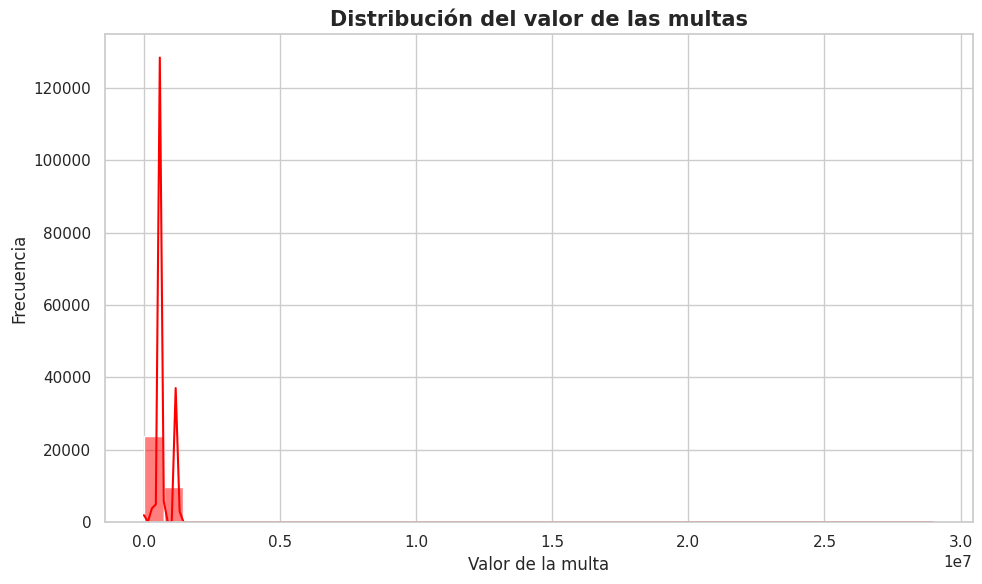

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Valor"], bins=40, kde=True, color="red")
plt.title("Distribución del valor de las multas", fontsize=15, fontweight="bold")
plt.xlabel("Valor de la multa")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()



**Interpretación:** La distribución permite observar la concentración de la mayoría de multas en ciertos rangos y detectar si la variable presenta asimetría o valores extremos.


### 5.2 Detección visual de outliers

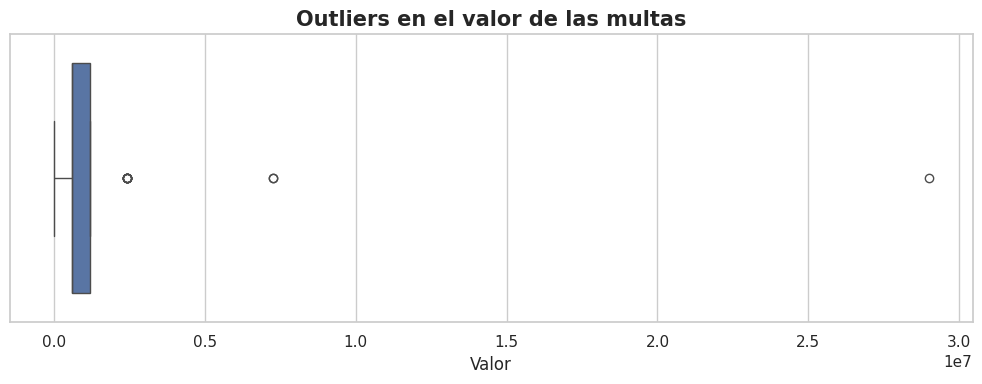

In [14]:

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Valor"])
plt.title("Outliers en el valor de las multas", fontsize=15, fontweight="bold")
plt.xlabel("Valor")
plt.tight_layout()
plt.show()



**Interpretación:** El boxplot permite identificar valores atípicos. En este caso, se observan multas considerablemente más altas que la mayoría de los registros, lo cual sugiere la presencia de sanciones excepcionales o acumuladas.


### 5.3 Top 10 infracciones más comunes

In [15]:

top10_infracciones = df["Infracciones Comparendo"].value_counts().head(10)
top10_infracciones


Infracciones Comparendo
C29    9569
C35    8405
D02    8015
C24    4052
D01    1073
C31     484
C15     376
D13     302
H02     279
D12     260
Name: count, dtype: int64

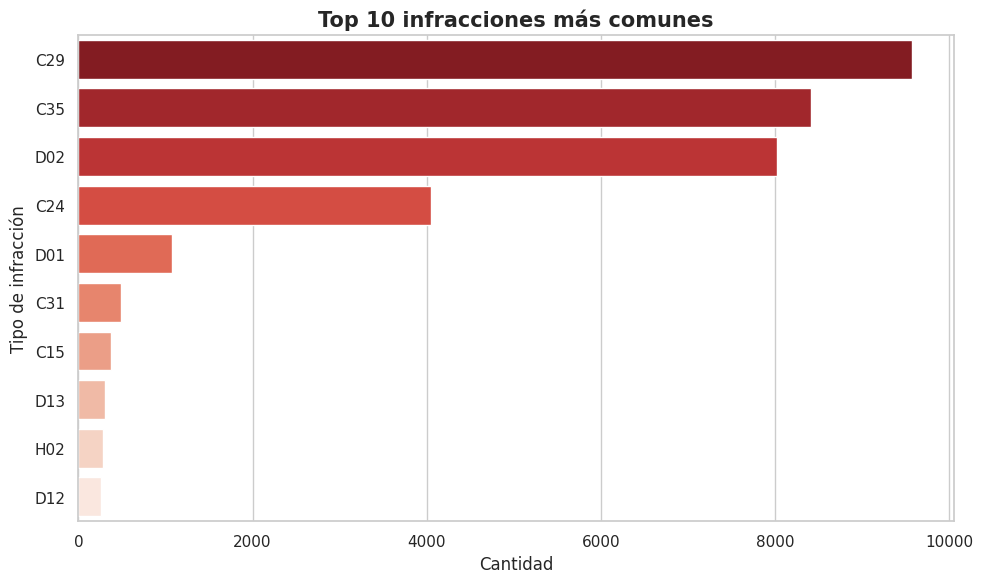

In [16]:

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_infracciones.values, y=top10_infracciones.index, hue=top10_infracciones.index, dodge=False, legend=False, palette="Reds_r")
plt.title("Top 10 infracciones más comunes", fontsize=15, fontweight="bold")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de infracción")
plt.tight_layout()
plt.show()



**Interpretación:** Se observa que pocas categorías concentran gran parte de los comparendos. Esto indica que el fenómeno está dominado por un grupo reducido de infracciones recurrentes.


### 5.4 Estadísticas descriptivas y análisis de outliers

In [17]:

valor = df["Valor"]

Q1 = valor.quantile(0.25)
Q2 = valor.quantile(0.50)
Q3 = valor.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(valor < limite_inferior) | (valor > limite_superior)].copy()

resumen = pd.DataFrame({
    "Media": [valor.mean()],
    "Mediana": [valor.median()],
    "Moda": [valor.mode().iloc[0]],
    "Desviación estándar": [valor.std()],
    "Valor mínimo": [valor.min()],
    "Q1": [Q1],
    "Q2 (Mediana)": [Q2],
    "Q3": [Q3],
    "IQR": [IQR],
    "Límite inferior": [limite_inferior],
    "Límite superior": [limite_superior],
    "Valor máximo": [valor.max()],
    "Cantidad de outliers": [len(outliers)]
}, index=["Valor"])

resumen


,Media,Mediana,Moda,Desviación estándar,Valor mínimo,Q1,Q2 (Mediana),Q3,IQR,Límite inferior,Límite superior,Valor máximo,Cantidad de outliers
Valor,"748,615.41","603,930.00",603930,"335,079.27",0,"603,930.00","603,930.00","1,207,860.00","603,930.00","-301,965.00","2,113,755.00",28988640,11


In [18]:

print("Outliers más altos:")
outliers.sort_values("Valor", ascending=False).head(10)


Outliers más altos:


,Nro Comparendo,Fecha Comparendo,Secretaría,Tipo Documento,Cédula Infractor,Nombre,Infracciones Comparendo,Valor,Dirección Infracción,Año,Mes_num,Mes
273,'99999999000006123252,2025-01-11,Sampues - Dptal Sucre,Cédula,157*****,MARIO ALBERTO,F,28988640,TR PLANETARICASINCELEJO - KM 110+700,2025,1,January
4221,'99999999000006235247,2025-04-18,Sampues - Dptal Sucre,Cédula,706*****,SERGIO ALONSO,F,7247160,VI SINCELEJO CALAMAR - KM 05+500,2025,4,April
9395,'99999999000006124052,2025-05-24,Sampues - Dptal Sucre,Cédula,101*****,JOSE RAUL,F,7247160,TR SINCELEJO CALAMAR - KM 5+500,2025,5,May
1436,'99999999000006123625,2025-02-21,Sampues - Dptal Sucre,Cédula,925*****,ORLANDO ENRIQUE,D02,2415720,TR PLANETARICASINCELEJO - KM 108,2025,2,February
1197,'99999999000006122238,2025-02-12,Sampues - Dptal Sucre,Cédula,921*****,ALEXANDER ENRIQUE,D02,2415720,VI SINCELEJO-CALAMAR - KM 5+500,2025,2,February
1531,'99999999000006019141,2025-02-26,Sampues - Dptal Sucre,Cédula,11006*****,NICOL DOUGLAS,D02,2415720,TR PLANETARICASINCELEJO - KM 104,2025,2,February
1573,'99999999000006019401,2025-02-27,Sampues - Dptal Sucre,Cédula,11028*****,ARMANDO CESAR,D07,2415720,TR PLANETARICASINCELEJO - KM 109,2025,2,February
3938,'99999999000006235237,2025-04-17,Sampues - Dptal Sucre,Cédula,10056*****,EVER JOSE,D02,2415720,VI LORICA - SAN ONOFRE - KM 61,2025,4,April
2609,'99999999000006236415,2025-03-29,Sampues - Dptal Sucre,Cédula,10033*****,LUIS MIGUEL,D01,2415720,VI LORICA SAN ONOFRE - KM 39+900,2025,3,March
15740,'99999999000006236847,2025-07-04,Sampues - Dptal Sucre,Cédula,110321****,FREY DAVID,D02,2415720,VI SINCELEJO-CALAMAR - KM 26,2025,7,July



**Interpretación:** La media, la mediana y la desviación estándar permiten resumir el comportamiento general de la variable `Valor`. El criterio del rango intercuartílico (IQR) permite detectar de manera objetiva los valores atípicos.


## 6. EDA bivariado

### 6.1 Infracciones por mes

In [19]:

infracciones_por_mes = df.groupby(["Mes_num", "Mes"]).size().reset_index(name="Cantidad")
infracciones_por_mes = infracciones_por_mes.sort_values("Mes_num")
infracciones_por_mes


,Mes_num,Mes,Cantidad
0,1,January,894
1,2,February,716
2,3,March,1053
3,4,April,4002
4,5,May,3762
5,6,June,4726
6,7,July,5136
7,8,August,3709
8,9,September,3408
9,10,October,5141


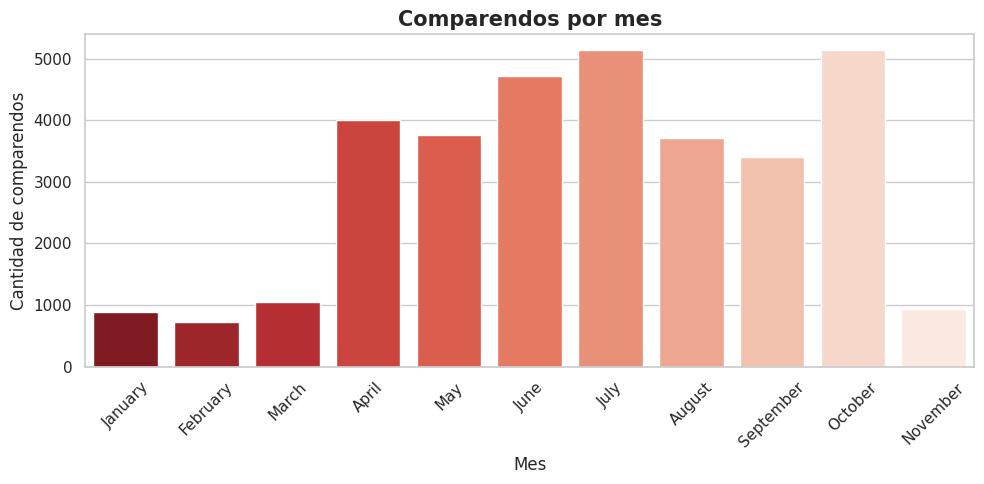

In [20]:

plt.figure(figsize=(10, 5))
sns.barplot(data=infracciones_por_mes, x="Mes", y="Cantidad", hue="Mes", dodge=False, legend=False, palette="Reds_r")
plt.title("Comparendos por mes", fontsize=15, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Cantidad de comparendos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Interpretación:** Este gráfico permite identificar variaciones temporales en la cantidad de infracciones. Algunos meses muestran mayor actividad, lo que puede estar asociado con mayor movilidad, temporadas vacacionales o más controles de tránsito.


### 6.2 Infracciones por mes y tipo de infracción

In [21]:

tabla = pd.crosstab(df["Mes"], df["Infracciones Comparendo"])
tabla = tabla.reindex(list(orden_meses.values())).dropna(how="all")
tabla


Infracciones Comparendo,B01,B02,B03,B05,B07,B08,B20,B22,C04,C06,C11,C13,C14,C15,C20,C22,C24,C27,C28,C29,C30,C31,C35,C37,C38,D01,D02,D03,D06,D07,D08,D12,D13,D15,F,H02,H03,H13
Mes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
January,1.00,17.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,19.00,69.00,0.00,0.00,300.00,0.00,0.00,1.00,0.00,67.00,83.00,1.00,0.00,89.00,152.00,8.00,6.00,0.00,0.00,18.00,38.00,0.00,1.00,18.00,0.00,1.00
February,1.00,17.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,36.00,0.00,2.00,296.00,0.00,0.00,0.00,0.00,48.00,72.00,1.00,0.00,69.00,116.00,3.00,3.00,2.00,0.00,13.00,23.00,0.00,0.00,11.00,0.00,0.00
March,2.00,16.00,7.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,21.00,32.00,0.00,2.00,342.00,0.00,1.00,0.00,0.00,82.00,140.00,1.00,0.00,49.00,295.00,6.00,4.00,2.00,0.00,16.00,27.00,0.00,0.00,6.00,0.00,0.00
April,4.00,15.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,29.00,18.00,0.00,0.00,192.00,0.00,0.00,"2,246.00",0.00,62.00,712.00,2.00,0.00,36.00,651.00,0.00,1.00,0.00,1.00,8.00,22.00,0.00,1.00,1.00,0.00,0.00
May,4.00,8.00,1.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,7.00,20.00,0.00,12.00,270.00,0.00,0.00,953.00,0.00,7.00,"1,240.00",0.00,1.00,50.00,"1,134.00",0.00,3.00,0.00,1.00,9.00,24.00,0.00,1.00,13.00,0.00,0.00
June,1.00,17.00,1.00,1.00,5.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,24.00,35.00,0.00,16.00,415.00,0.00,0.00,"1,282.00",0.00,35.00,"1,432.00",4.00,0.00,100.00,"1,289.00",1.00,5.00,0.00,0.00,18.00,28.00,0.00,0.00,15.00,0.00,0.00
July,4.00,36.00,6.00,0.00,8.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,51.00,1.00,37.00,599.00,1.00,1.00,"1,030.00",0.00,78.00,"1,551.00",0.00,0.00,180.00,"1,404.00",1.00,12.00,1.00,1.00,55.00,41.00,0.00,0.00,35.00,0.00,0.00
August,4.00,19.00,1.00,0.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,61.00,0.00,17.00,586.00,0.00,0.00,998.00,0.00,37.00,910.00,1.00,0.00,123.00,814.00,1.00,4.00,0.00,2.00,38.00,48.00,0.00,0.00,33.00,0.00,0.00
September,3.00,25.00,3.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,40.00,1.00,11.00,598.00,1.00,0.00,753.00,0.00,21.00,791.00,4.00,0.00,182.00,826.00,2.00,2.00,1.00,1.00,31.00,22.00,0.00,0.00,89.00,0.00,0.00


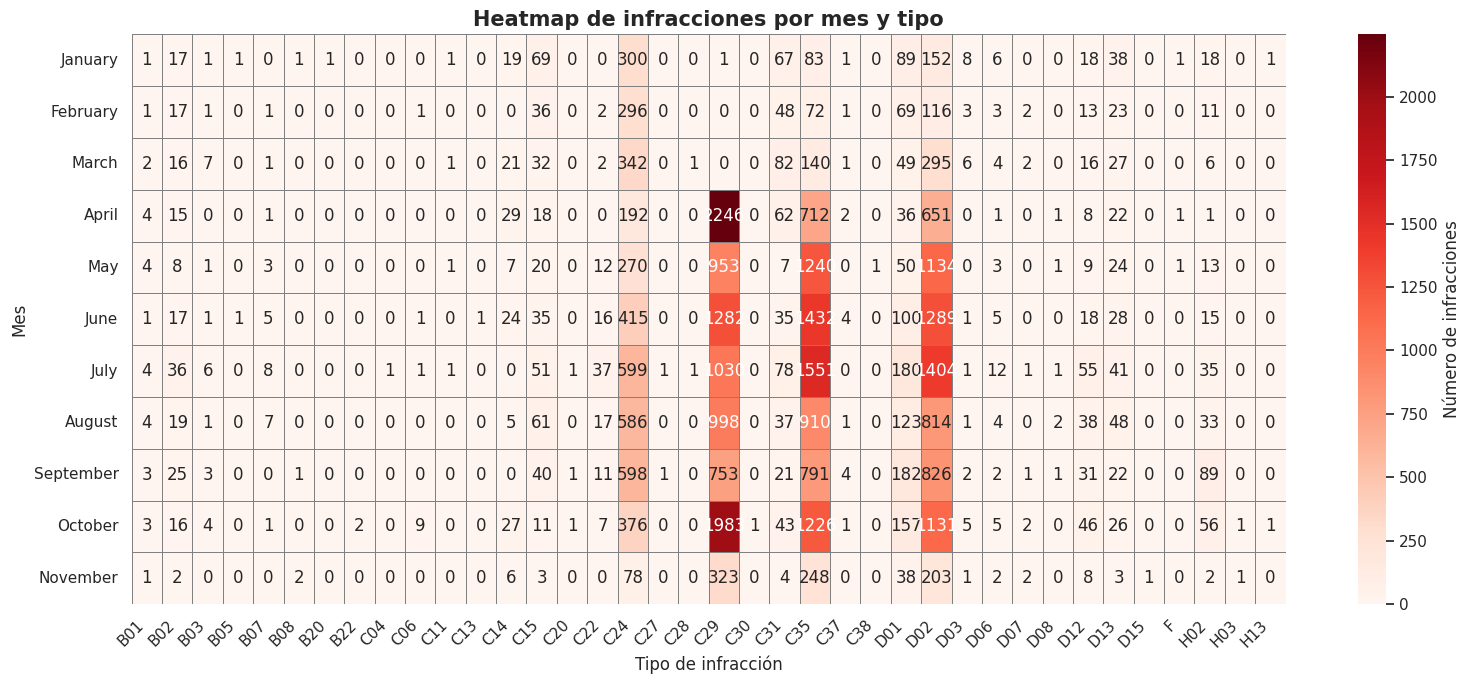

In [24]:
plt.figure(figsize=(16, 7))
sns.heatmap(
    tabla,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Número de infracciones"}
)
plt.title("Heatmap de infracciones por mes y tipo", fontsize=15, fontweight="bold")
plt.xlabel("Tipo de infracción")
plt.ylabel("Mes")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



**Interpretación:** El heatmap muestra qué tipos de infracción dominan en cada mes. Las celdas con colores más intensos representan una mayor frecuencia y permiten detectar patrones recurrentes a lo largo del tiempo.


### 6.3 Comparación del valor de la multa por tipo de infracción

/tmp/ipykernel_33694/4076117073.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


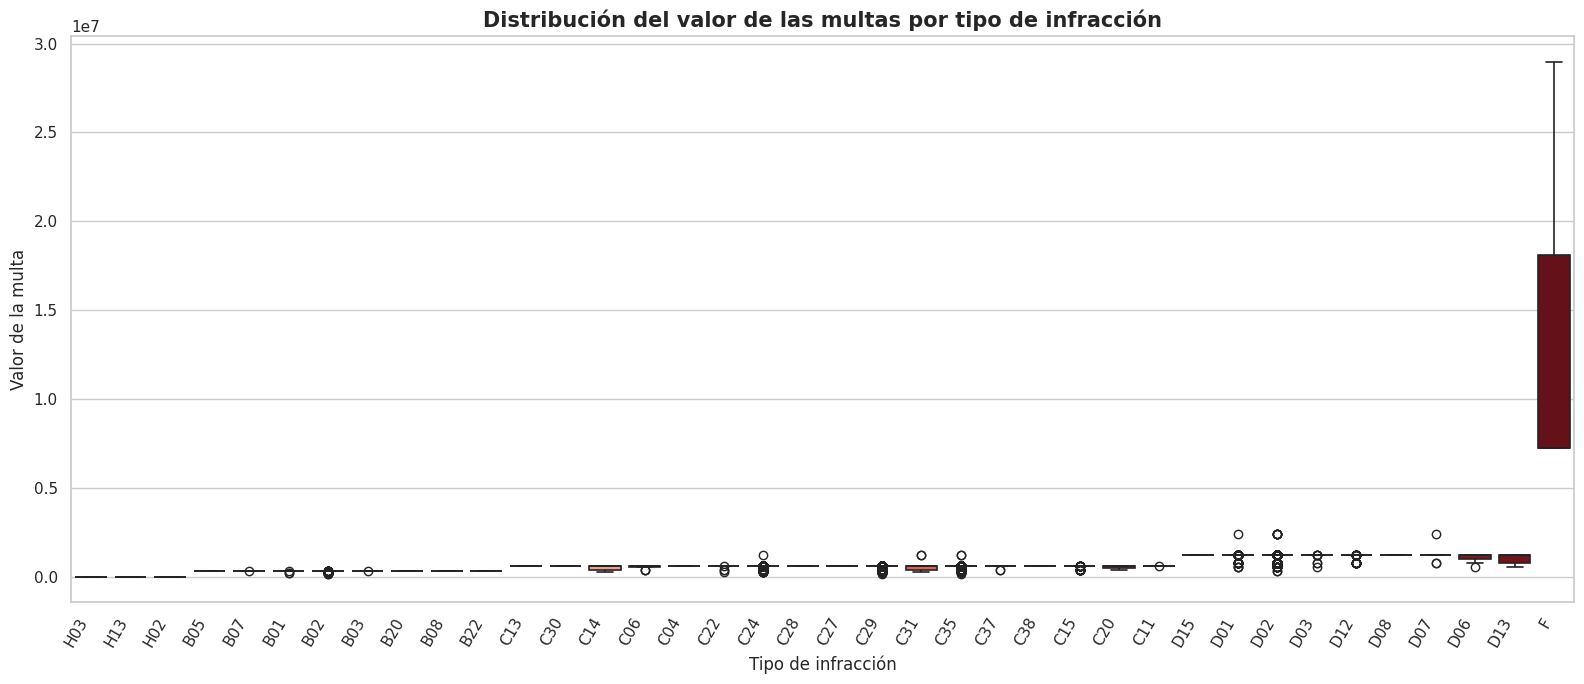

In [25]:

orden_boxplot = df.groupby("Infracciones Comparendo")["Valor"].median().sort_values().index

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=df,
    x="Infracciones Comparendo",
    y="Valor",
    order=orden_boxplot,
    palette="Reds",
    linewidth=1.2
)
plt.xticks(rotation=60, ha="right")
plt.title("Distribución del valor de las multas por tipo de infracción", fontsize=15, fontweight="bold")
plt.xlabel("Tipo de infracción")
plt.ylabel("Valor de la multa")
plt.tight_layout()
plt.show()



**Interpretación:** Este gráfico permite comparar la dispersión del valor de las multas entre tipos de infracción. Se evidencia que algunas infracciones presentan valores mucho más altos y mayor variabilidad que otras.


## 7. Conclusiones finales


1. El dataset presenta una estructura adecuada para el análisis y no muestra problemas críticos de calidad en las variables principales.
2. El análisis univariado evidenció que el valor de las multas tiene una distribución asimétrica y presencia de outliers.
3. Un grupo reducido de infracciones concentra la mayor cantidad de comparendos, lo cual sugiere comportamientos recurrentes en los conductores.
4. El análisis por mes mostró variaciones temporales en la frecuencia de infracciones, con periodos de mayor incidencia.
5. El heatmap permitió identificar patrones de recurrencia entre mes y tipo de infracción.
6. La comparación del valor de las multas por tipo de infracción muestra que no todas tienen el mismo impacto económico y que algunas categorías presentan sanciones considerablemente mayores.

En conjunto, este EDA deja preparado el dataset para análisis posteriores, como segmentación, modelado predictivo o formulación de estrategias de prevención vial.
